# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Payton Gergen

**Date:** 9/2/26

### Question 1

#### 1. Clean `Price` variable

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load data
airbnb = pd.read_csv("data/airbnb_hw.csv")

In [3]:
airbnb.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [4]:
airbnb["Price"] = airbnb["Price"].str.replace(",", "") # remove commas from numbers
airbnb["Price"] = airbnb["Price"].astype(float) # convert strings to float
airbnb["Price"].max() # Check that values above 999 are included as numbers

np.float64(10000.0)

In [5]:
airbnb["Price"].isnull().sum() # Check if any values are null

np.int64(0)

#### 2. Clean `subject_injury`

In [6]:
police = pd.read_csv("data/mn_police_use_of_force.csv")
police.head()

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [7]:
# Inspect what entries are included in subject_injury
police["subject_injury"].unique()

<StringArray>
[nan, 'No', 'Yes']
Length: 3, dtype: str

In [8]:
# Determine how many entries in subject_injury are nan
police["subject_injury"].isnull().sum()

np.int64(9848)

In [9]:
police["subject_injury"].isnull().sum() / len(police["subject_injury"]) # percent of values missing

np.float64(0.7619342359767892)

9,848 of the entries (76.19%) in `subject_injury` are NaN. The amount of missing values is concerning because this represents such a significant portion of the data, and if the missing values are correlated with another variable in the table, then the relationship between `subject_injury` and other variables may be unrepresentative of the truth. All values are Yes, No, or NaN, so additional cleaning is not necessary. Now, I will crosstabulagte with `force_type` to determine whether there are patterns as to where missing values occur.

In [10]:
pd.crosstab(police["subject_injury"], police["force_type"], dropna=False) # crosstabulate frequency

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172
NaN,2,7051,1421,0,27,74,87,0,170,31,985


In [11]:
pd.crosstab(police["subject_injury"], police["force_type"], dropna=False, normalize="columns") # crosstabulate percentages

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0.0,0.115907,0.082235,1.0,0.317308,0.22973,0.0,0.333333,0.0,0.025974,0.114767
Yes,0.5,0.136373,0.025738,0.0,0.423077,0.27027,0.0,0.666667,0.0,0.571429,0.131599
NaN,0.5,0.747720,0.892028,0.0,0.259615,0.50000,1.0,0.000000,1.0,0.402597,0.753634


There are patterns regarding where `subject_injury` contains missing values. For instance, all of the instances of Maximal Restraint Technique are missing whether the subject was injured. A disproportinate amount of values are also missing in cases of Chemical Irritant.

### Question 2

#### 1. Open shark attack file

In [65]:
shark = pd.read_excel("data/GSAF5.xls")
shark.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 2. Drop empty columns

In [66]:
shark["Unnamed: 21"].unique()

<StringArray>
[nan, 'stopped here']
Length: 2, dtype: str

In [77]:
not_empty = []
for col in shark.columns:
    if shark.loc[:, col].isna().sum() <= 7116:
        not_empty.append(col)
not_empty


['Date',
 'Year',
 'Type',
 'Country',
 'State',
 'Location',
 'Activity',
 'Name',
 'Sex',
 'Age',
 'Injury',
 'Fatal Y/N',
 'Time',
 'Species ',
 'Source',
 'pdf',
 'href formula',
 'href',
 'Case Number',
 'Case Number.1',
 'original order']

In [80]:
shark = shark[not_empty]
shark

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Fatal Y/N,Time,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,N,1330hrs,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,N,1700hrs,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,N,?,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,N,1615hrs,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,N,1300hrs,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7112,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,...,Y,NaN,NaN,"H. Taunton; N. Bartlett, p. 234",ND-0005-RoebuckBay.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0005,ND.0005,6.0
7113,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,...,Y,NaN,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND-0004-Ahmun.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0004,ND.0004,5.0
7114,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,...,Y,NaN,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND-0003-Ocracoke_1900-1905.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0003,ND.0003,4.0
7115,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,...,Y,NaN,NaN,"The Sun, 10/20/1938",ND-0002-JulesPatterson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0002,ND.0002,3.0


#### 3. Clean and analyze year variable

In [ ]:
# Convert to int
shark["Year"] = shark["Year"].astype('Int64')
shark["Year"]

0       2026
1       2026
2       2026
3       2026
4       2026
        ... 
7112       0
7113       0
7114       0
7115       0
7116       0
Name: Year, Length: 7117, dtype: Int64

In [ ]:
# Examine values in year
shark["Year"].unique()

<IntegerArray>
[2026, 2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017,
 ...
 1580, 1555, 1554, 1543, 1518, 1500, 1000,   77,    5,    0]
Length: 262, dtype: Int64

In [107]:
# Filter to data before 1940
shark["Year"] = shark["Year"].mask(shark["Year"] < 1940, np.nan)
shark["Year"].unique()

<IntegerArray>
[2026, 2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, <NA>, 2016, 2015,
 2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002,
 2001, 2000, 1999, 1998, 1997, 1996, 1995, 1984, 1994, 1993, 1992, 1991, 1990,
 1989, 1969, 1988, 1987, 1986, 1985, 1983, 1982, 1981, 1980, 1979, 1978, 1977,
 1976, 1975, 1974, 1973, 1972, 1971, 1970, 1968, 1967, 1966, 1965, 1964, 1963,
 1962, 1961, 1960, 1959, 1958, 1957, 1956, 1955, 1954, 1953, 1952, 1951, 1950,
 1949, 1948, 1947, 1946, 1945, 1944, 1943, 1942, 1941, 1940]
Length: 88, dtype: Int64

(array([ 252.,  351.,  582.,  357.,  292.,  389.,  591.,  805., 1131.,
         831.]),
 array([1940. , 1948.6, 1957.2, 1965.8, 1974.4, 1983. , 1991.6, 2000.2,
        2008.8, 2017.4, 2026. ]),
 <BarContainer object of 10 artists>)

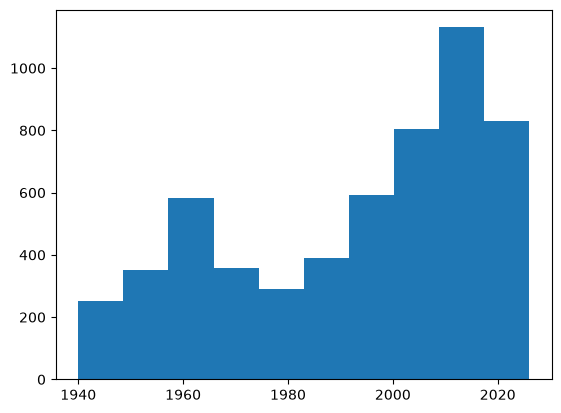

In [108]:
# Plot year
plt.hist(shark["Year"])

Overall, the number of attacks (or at least the number of attacks reported in this dataset) has been increasing since 1980.

#### 4. Clean and plot age variable

In [105]:
# Convert to int
shark["Age"] = pd.to_numeric(shark["Age"], errors = "coerce")
shark["Age"]

0        NaN
1       43.0
2        NaN
3       27.0
4       71.0
        ... 
7112     NaN
7113     NaN
7114     NaN
7115     NaN
7116    15.0
Name: Age, Length: 7117, dtype: float64

(array([ 141., 1075.,  998.,  678.,  418.,  322.,  197.,   79.,   34.,
           6.]),
 array([ 1. ,  9.6, 18.2, 26.8, 35.4, 44. , 52.6, 61.2, 69.8, 78.4, 87. ]),
 <BarContainer object of 10 artists>)

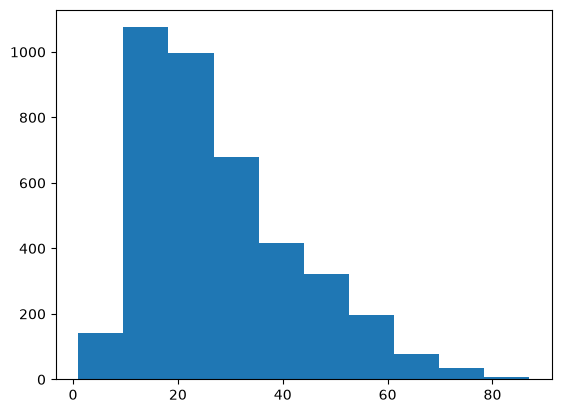

In [106]:
plt.hist(shark["Age"])

#### 5. Proportion of male victims

In [109]:
shark["Sex"].unique()

<StringArray>
['F', 'M', 'M ', 'M F', '?', 'F ', nan, ' M', 'm', 'lli', 'M x 2', 'N', '.']
Length: 13, dtype: str

In [130]:
# Change M and F labels with different formatting to be counted
shark["Sex"] = shark["Sex"].replace({"M ": "M", 
                                     "F ": "F", 
                                     " M": "M", 
                                     "m": "M"})
shark["Sex"].unique()

<StringArray>
['F', 'M', 'M F', '?', nan, 'lli', 'M x 2', 'N', '.']
Length: 9, dtype: str

In [118]:
len(shark["Sex"])

7117

In [117]:
(shark["Sex"]=="M").sum()

np.int64(5713)

In [121]:
(shark["Sex"]=="M").sum() / len(shark["Sex"])

np.float64(0.80272586764086)

In [120]:
(shark["Sex"]=="M").sum() + (shark["Sex"]=="F").sum()

np.int64(6531)

5713 of 7117 (80.27%) recorded occurances were male (although only 6531 of those values have a properly labeled gender).

#### 6. Clean and analyze `Type`

In [123]:
shark["Type"].unique()

<StringArray>
[         'Unprovoked',            'Provoked',        'Questionable',
          'UNprovoked',          'unprovoked',           ' Provoked',
          'Watercraft',        'Sea Disaster',                   nan,
                   '?',         'Unconfirmed',          'Unverified',
             'Invalid', 'Under investigation',                'Boat']
Length: 15, dtype: str

In [129]:
shark["Type"] = shark["Type"].replace({"UNprovoked": "Unprovoked", 
                                       "unprovoked": "Unprovoked", 
                                       " Provoked": "Provoked", 
                                       "Questionable": np.nan, 
                                       "Watercraft": np.nan, 
                                       "Sea Disaster": np.nan, 
                                       "?": np.nan, 
                                       "Unconfirmed": np.nan, 
                                       "Unverified": np.nan, 
                                       "Invalid": np.nan, 
                                       "Under investigation": np.nan, 
                                       "Boat": np.nan})
shark["Type"].unique()

<StringArray>
['Unprovoked', 'Provoked', nan]
Length: 3, dtype: str

In [131]:
(shark["Type"] == "Unprovoked").sum()

np.int64(5263)

In [132]:
len(shark["Type"])

7117

In [133]:
(shark["Type"] == "Unprovoked").sum() / len(shark["Type"])

np.float64(0.7394969790642124)

5263 out of 7117 (73.95%) of the occurance are unprovoked.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]